Tworzenie Explanera...
Obliczanie wartości Shapley'a dla pełnego zbioru testowego (to potrwa dłuższą chwilę)...

Generowanie wykresu Summary Plot na pełnych danych...


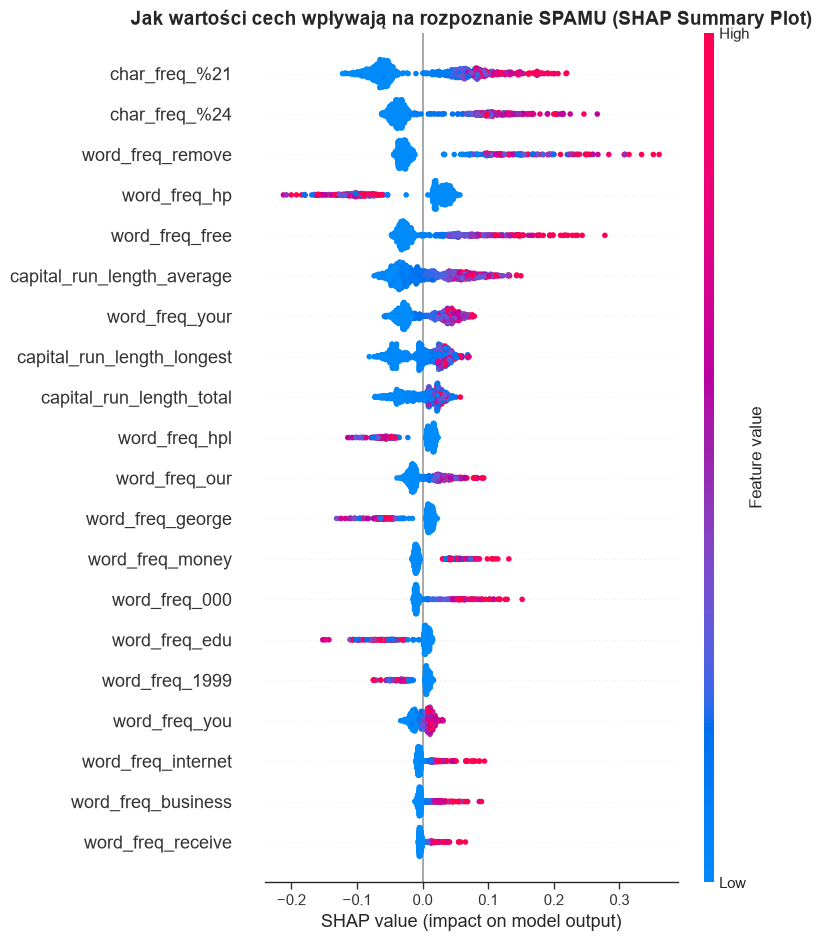


Generowanie lokalnego wyjaśnienia dla jednej, konkretnej wiadomości...


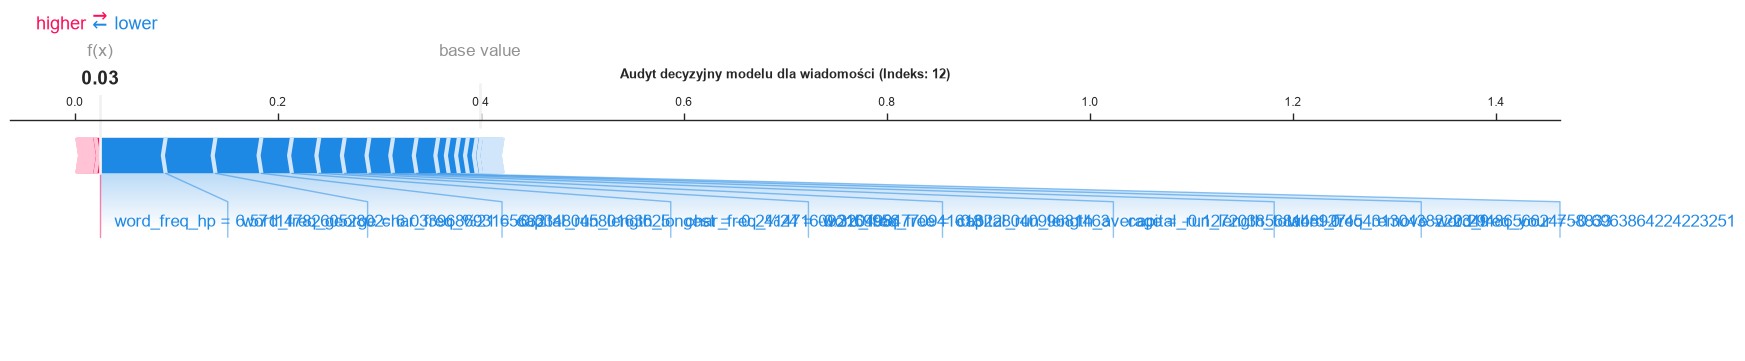

In [7]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Ustawienie estetyki dla wykresów matplotlib
sns.set_theme(style="white", context="paper")

# 1. Wczytanie pełnych danych testowych i modelu
X_test = pd.read_csv('../data/processed/X_test.csv')
best_model = joblib.load('../models/random_forest_tuned.pkl')

# 2. Inicjalizacja SHAP w notatniku
shap.initjs()

print("Tworzenie Explanera...")
explainer = shap.TreeExplainer(best_model)

print("Obliczanie wartości Shapley'a dla pełnego zbioru testowego (to potrwa dłuższą chwilę)...")
# check_additivity=False zabezpiecza przed wewnętrznymi błędami biblioteki
shap_values = explainer.shap_values(X_test, check_additivity=False)

# ==========================================
# NAPRAWA STRUKTURY DANYCH (Zgodność z nowym API SHAP)
# ==========================================
# 1. Wyciągnięcie pojedynczej wartości bazowej dla klasy Spam (indeks 1)
if isinstance(explainer.expected_value, (list, np.ndarray)):
    expected_value_spam = float(explainer.expected_value[1])
else:
    expected_value_spam = float(explainer.expected_value)

# 2. Wyciągnięcie tablicy wpływu cech tylko dla klasy Spam
if isinstance(shap_values, list):
    shap_values_spam = shap_values[1]
elif isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
    # Nowsze wersje SHAP zwracają kształt (próbki, cechy, klasy)
    shap_values_spam = shap_values[:, :, 1]
else:
    shap_values_spam = shap_values

# ==========================================
# WYKRES 1: Globalna Wyjaśnialność (Summary Plot)
# ==========================================
print("\nGenerowanie wykresu Summary Plot na pełnych danych...")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_spam, X_test, show=False)
plt.title("Jak wartości cech wpływają na rozpoznanie SPAMU (SHAP Summary Plot)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ==========================================
# WYKRES 2: Lokalna Wyjaśnialność (Sekcja "Czarna Skrzynka")
# ==========================================
print("\nGenerowanie lokalnego wyjaśnienia dla jednej, konkretnej wiadomości...")

# Indeks wiadomości do analizy (możesz zmienić na dowolny od 0 do 840)
iloc_index = 12

shap.force_plot(
    expected_value_spam, 
    shap_values_spam[iloc_index], 
    X_test.iloc[iloc_index, :],
    matplotlib=True, 
    show=False
)
plt.title(f'Audyt decyzyjny modelu dla wiadomości (Indeks: {iloc_index})', pad=30, fontweight='bold')
plt.show()

wykres SHAP (Summary Plot)?

 *   Oś pionowa (Y): Cechy posortowane są od najważniejszej (na samej górze) do najmniej ważnej (na dole). Wynik idealnie pokrywa się z wykresem słupkowym z poprzedniego etapu.

 *   Kolor (Feature value): Reprezentuje wartość danej cechy u konkretnego nadawcy. Kolor czerwony oznacza wysoką wartość (np. dużo wykrzykników w mailu), a kolor niebieski niską wartość (brak wykrzykników).

 *   Oś pozioma (X - SHAP value): Pokazuje, jak dana cecha wpłynęła na decyzję. Kropki po prawej stronie (powyżej zera) "pchają" algorytm do uznania wiadomości za SPAM. Kropki po lewej stronie (poniżej zera) "bronią" wiadomości, klasyfikując ją jako HAM (prawdziwy e-mail).

### Wnioski z wykresu
* Identyfikatory SPAMU (Czerwone kropki po prawej stronie): Spójrz na zmienne char_freq_%21 (!), char_freq_%24 ($), word_freq_remove oraz word_freq_free. Widać wyraźnie, że wysokie wartości tych cech (kolor czerwony) drastycznie przesuwają decyzję modelu w prawo (w kierunku spamu). Oznacza to, że nadużywanie wykrzykników, symbolu waluty oraz słów oznaczających darmowe oferty to najsilniejsze sygnały ostrzegawcze.

* Bariery ochronne normalnej korespondencji (Czerwone kropki po lewej stronie): Zwróć uwagę na zmienne word_freq_hp, word_freq_hpl, word_freq_george oraz word_freq_edu. Tutaj mechanizm działa odwrotnie – wysokie wartości (czerwone kropki) znajdują się głęboko po lewej stronie wykresu. Model nauczył się, że jeśli w wiadomości często pojawiają się słowa związane z pracą badawczą HP, uczelniami (.edu) lub imieniem twórcy zbioru (George), to jest to niemal gwarancja, że wiadomość pochodzi od zaufanego nadawcy.

* Wpływ braku cechy (Niebieskie kropki): Zauważ gęste, niebieskie skupiska w okolicach zera. Oznaczają one, że sam fakt braku danego słowa (np. braku słowa "free") nie jest silnym sygnałem w żadną ze stron – po prostu minimalnie przesuwa szalę w lewo lub w prawo, pozostawiając ostateczną decyzję innym, bardziej wyraźnym cechom.